In [106]:
import json

# Demonstration of how to load a file that contains secrets without accidentally leaking those secrets
with open('C:\\Users\\aznma\\Documents\\Github Projects\\DATA320\\credentials.json') as f:
    data = json.load(f)

    # If you want your data to be secure, don't print this variable out!
    # Jupyter will retain a cached version of any printed data and it can be
    # accidentally committed to version control.
    secret_key = data['mongodb']

# We can safely print the length of the secret key. That won't leak any sensitive information.
print(f"My secret key is {len(secret_key)} characters in length.")

My secret key is 73 characters in length.


In [107]:
import pymongo
import certifi

# Connect to the database using known good certificates
client = pymongo.MongoClient(secret_key, tlsCAFile=certifi.where())
print(f"Using MongoDB version {client.server_info()['version']}.")

# Check what databases exist on this server
all_databases = client.list_database_names()
print(f"This MongoDB server has the databases {all_databases}")

# If we know the correct database to talk to, we connect like this:
data320 = client['data320']

# Here is the list of collections within my database
all_collections = data320.list_collection_names()
print(f"This database has the collections {all_collections}")

Using MongoDB version 8.0.15.
This MongoDB server has the databases ['data320', 'admin', 'local']
This database has the collections ['IMDB', 'metacritic', 'IMDB_Pipeline_View']


In [108]:
import pandas as pd

# Retrieve all records from a collection - this can be a large amount of data!
cursor = data320["IMDB_Pipeline_View"].find()

# Convert this information into a Pandas dataframe
imdb_view = pd.DataFrame(cursor)

# Make sure we've read the information correctly
imdb_view.head()

,_id,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,release_year,release_month,opening_weekend_first,is_opening_weekend_first_usd,opening_weekend_value,opening_weekend_usd,budget_first,is_budget_first_usd,budget_value,budget_usd
0,6366dfccfcbf171967d87837,"$300,000 (estimated)","Donald Pleasence, Jamie Lee Curtis, Nancy Kyes...","TV-14, TV-MA::(IFC rating), R","Compass International Pictures, Falcon Interna...",John Carpenter,"Horror, Thriller","$70,000,000",77651,None,...,1978,10,None,False,None,None,"$300,000",True,"{'match': '300,000', 'idx': 1, 'captures': ['3...",300000
1,6366dfcffcbf171967d87838,"$6,000,000 (estimated)","John Travolta, Olivia Newton-John, Stockard Ch...","TV-14::(D), TV-PG::(DVD rating), PG, PG-13","Paramount Pictures, Robert Stigwood Organizati...",Randal Kleiser,"Comedy, Musical, Romance","$394,955,690",77631,"$60,759, 11 Jul 2010",...,1978,6,"$60,759",True,"{'match': '60,759', 'idx': 1, 'captures': ['60...",60759,"$6,000,000",True,"{'match': '6,000,000', 'idx': 1, 'captures': [...",6000000
2,6366dfd1fcbf171967d87839,None,"Brooke Shields, Keith Carradine, Susan Sarando...","TV-MA, R",Paramount Pictures,Louis Malle,Drama,None,78111,None,...,1978,1,None,False,None,None,None,False,None,None
3,6366dfd4fcbf171967d8783a,"$3,000,000 (estimated)","Tom Hulce, Stephen Furst, Mark Metcalf, Mary L...","TV-14::(DLSV, TV Rating.), TV-MA::(IFC rating), R","Universal Pictures, Oregon Film Factory, Stage...",John Landis,Comedy,"$3,371,006",77975,"$201,747, 23 Sep 1979",...,1978,7,"$201,747",True,"{'match': '201,747', 'idx': 1, 'captures': ['2...",201747,"$3,000,000",True,"{'match': '3,000,000', 'idx': 1, 'captures': [...",3000000
4,6366dfd6fcbf171967d8783b,"$650,000 (estimated)","David Emge, Ken Foree, Scott H. Reiniger, Gayl...",Unrated,"Laurel Group, Dawn Associates",George A. Romero,"Horror, Thriller","$55,000,000",77402,None,...,1978,9,None,False,None,None,"$650,000",True,"{'match': '650,000', 'idx': 1, 'captures': ['6...",650000


In [109]:
import pandas

cursor = data320["IMDB_Pipeline_View"].find({ "genres": { "$in": ["Comedy"] } })
comedy_films = pandas.DataFrame(cursor)

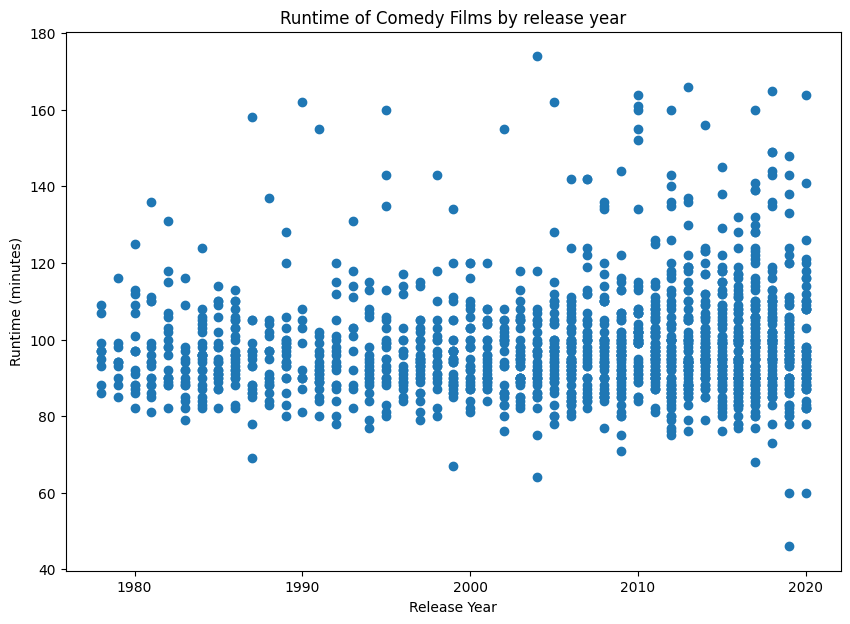

In [110]:
# extract, transform, load
# pipeline will:
# 1. convert strings w nums to numeric types (remove $)
# 2. convert strings w dates to datetime types (extract year/month/day)
# 3. convert strings w lists of names to array of names
# 4. use reg expressions to extract MPAA/TV ratings into sep fields
# 5. run report in jupyter to retrieve data and plot it

# aggregation pipeline is a list of transformations to apply to the data before giving you data

from matplotlib import pyplot

pyplot.figure(figsize=(10,7))
pyplot.scatter(comedy_films['release_year'], comedy_films['runtime'])
pyplot.title('Runtime of Comedy Films by release year')
pyplot.xlabel('Release Year')
pyplot.ylabel('Runtime (minutes)')
pyplot.show()


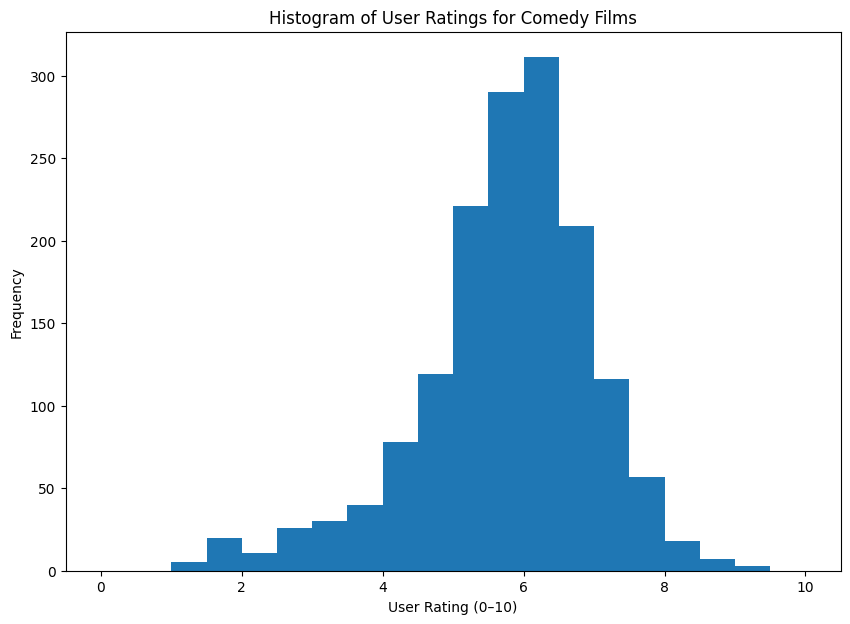

In [111]:
import numpy as np
from matplotlib import pyplot

pyplot.figure(figsize=(10,7))
pyplot.hist(comedy_films["user_rating"], bins=np.linspace(0, 10, 21)) 
pyplot.title("Histogram of User Ratings for Comedy Films")
pyplot.xlabel("User Rating (0–10)")
pyplot.ylabel("Frequency")
pyplot.show()


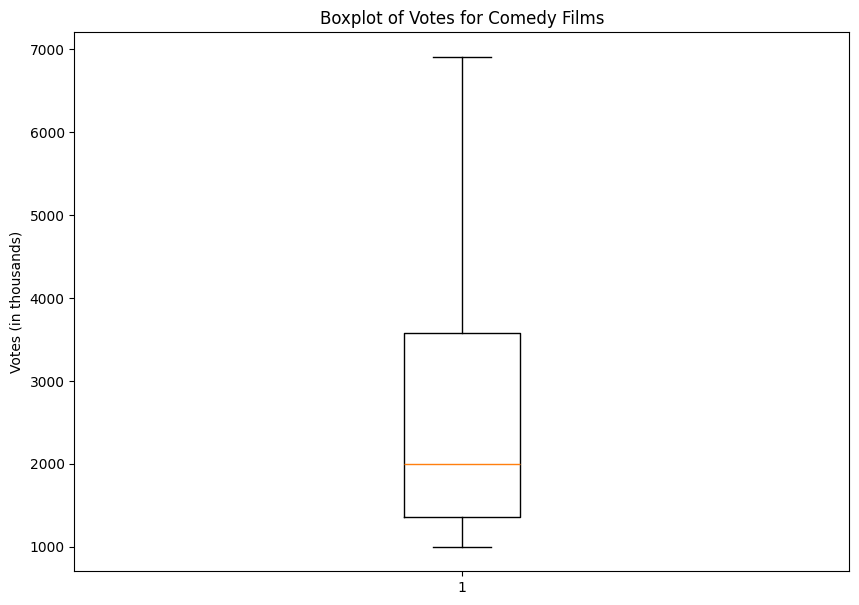

In [112]:
from matplotlib import pyplot

y = comedy_films['votes']

q1, q3 = y.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
y_iqr = y[(y >= lo) & (y <= hi)]

pyplot.figure(figsize=(10,7))
pyplot.boxplot(y_iqr.to_numpy(), showfliers=False)
pyplot.title("Boxplot of Votes for Comedy Films")
pyplot.ylabel("Votes (in thousands)")
pyplot.show()


```json
[
    {
        '$addFields': {
            'gross_sales': '$gross_sales', 
            'is_gross_sales_usd': {
                '$regexMatch': {
                    'input': '$gross_sales', 
                    'regex': re.compile(r"^\\$")
                }
            }, 
            'gross_sales_value': {
                '$regexFind': {
                    'input': '$gross_sales', 
                    'regex': re.compile(r"([\\d,]+)")
                }
            }
        }
    }, {
        '$addFields': {
            'gross_sales': '$gross_sales', 
            'gross_sales_usd': {
                '$switch': {
                    'branches': [
                        {
                            'case': '$is_gross_sales_usd', 
                            'then': {
                                '$toDecimal': {
                                    '$replaceAll': {
                                        'input': '$gross_sales_value.match', 
                                        'find': ',', 
                                        'replacement': ''
                                    }
                                }
                            }
                        }
                    ], 
                    'default': None
                }
            }
        }
    }, {
        '$addFields': {
            'raw_mpaa': '$certification', 
            'mpaa': {
                '$first': {
                    '$setIntersection': [
                        [
                            'G', 'PG', 'PG-13', 'R', 'NC-17'
                        ], {
                            '$split': [
                                '$certification', ', '
                            ]
                        }
                    ]
                }
            }
        }
    }, {
        '$addFields': {
            'release_year': {
                '$year': '$release_date'
            }, 
            'release_month': {
                '$month': '$release_date'
            }
        }
    }, {
        '$addFields': {
            'opening_weekend_first': {
                '$arrayElemAt': [
                    {
                        '$split': [
                            '$opening_weekend', ', '
                        ]
                    }, 0
                ]
            }
        }
    }, {
        '$addFields': {
            'is_opening_weekend_first_usd': {
                '$regexMatch': {
                    'input': '$opening_weekend_first', 
                    'regex': re.compile(r"\\$")
                }
            }, 
            'opening_weekend_value': {
                '$regexFind': {
                    'input': '$opening_weekend_first', 
                    'regex': re.compile(r"([\\d,]+)")
                }
            }
        }
    }, {
        '$addFields': {
            'opening_weekend': '$opening_weekend', 
            'opening_weekend_usd': {
                '$switch': {
                    'branches': [
                        {
                            'case': '$is_opening_weekend_first_usd', 
                            'then': {
                                '$toDecimal': {
                                    '$replaceAll': {
                                        'input': '$opening_weekend_value.match', 
                                        'find': ',', 
                                        'replacement': ''
                                    }
                                }
                            }
                        }
                    ], 
                    'default': None
                }
            }
        }
    }, {
        '$addFields': {
            'budget_first': {
                '$arrayElemAt': [
                    {
                        '$split': [
                            '$budget', ' '
                        ]
                    }, 0
                ]
            }
        }
    }, {
        '$addFields': {
            'is_budget_first_usd': {
                '$regexMatch': {
                    'input': '$budget_first', 
                    'regex': re.compile(r"\\$")
                }
            }, 
            'budget_value': {
                '$regexFind': {
                    'input': '$budget_first', 
                    'regex': re.compile(r"([\\d,]+)")
                }
            }
        }
    }, {
        '$addFields': {
            'budget': '$budget', 
            'budget_usd': {
                '$switch': {
                    'branches': [
                        {
                            'case': '$is_budget_first_usd', 
                            'then': {
                                '$toDecimal': {
                                    '$replaceAll': {
                                        'input': '$budget_value.match', 
                                        'find': ',', 
                                        'replacement': ''
                                    }
                                }
                            }
                        }
                    ], 
                    'default': None
                }
            }
        }
    }
]
```